<a href="https://colab.research.google.com/github/kebalriv25-max/Analisis_de_embudo_Retencion_MercadoLibre/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

El objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se trabajará con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

se realizara lo siguiente: **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

---
## 🧩 Paso 1: Cargar y explorar

En esta etapa, validaremos que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Actividades realizadas:**  
- Importar las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Cargar los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guardar los DataFrames en las variables: `plans`, `users`, `usage`.  
- Mostrar las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Actividades realizadas:**  
- Revisar el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usar `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Actividades realizadas:**  
- Contar valores nulos por columna para cada dataset.
- Calcular la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
#usage.isna().sum()
usage.isna().mean()

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64

**Valores nulos**  
-Analizamos que columnas tienen valores faltantes y en qué proporción
- En "users" ["city","churn_date"] con [11.7%, 88.3%] y en "usage" ["date","duration","length"] con [0.1%, 55.1%, 44.7%] respectivamente.
- Rpt: En "users" ["imputar", "ignorar"] y en "usage" ["imputar","ignorar","ignorar"] respectivamente.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Actividades Realizadas:**
- Explorar las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explorar las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene un promedio de 11999.5, un IQR de 2000.0, tienen baja variabilidad.
- La columna `age` presenta valores atipicos -999.0 como minimo, un IQR de 31.0, tienen alta variabilidad.

In [ ]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id`  tiene alta variabilidad, tiene valores extremos muy distantes entre 1 y 40000(posibles outliers), `user_id` tiene baja variabilidad.
- Las columnas `duration` y `length` presentan valores atipicos como 0.0 (Sentinels), por otro lado `length` tambien presenta un valor maximo muy distante del valor promedio(posible outliers)

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())
print()
print("valores nulos")
print(users[columnas_user].isna().sum())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

valores nulos
city    469
plan      0
dtype: int64


- La columna `city` tiene 7 columnas unicas, en el cual se tiene el nombre de "Bogotá" repitiendose 808 veces.
- La columna `plan` tiene 2 columnas unicas, en el cual se tiene el nombre de "Basico" repitiendose 2595 veces.

In [ ]:

# explorar columna categórica de usage
print(usage['type'].value_counts())
print()
print("valores nulos")
print(usage['type'].isna().sum())


text    22092
call    17908
Name: type, dtype: int64

valores nulos
0


- La columna `type` tiene 2 columnas unicas, en el cual se tiene el nombre de "text" repitiendose 22092 veces.


**Valores inválidos o sentinels**  
- La columna"city" dentro de "users" presenta 469 valores nulos. Por tanto, se tendria que imputar los valores nulos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Actividades realizadas:**  
- Convertir las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisar cuántas veces aparece cada año.
- Identificar fechas imposibles (ej. años futuros o negativos).

Tomar en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, tenemos los años 2022,2023,2024 y 2026. No se tienen valores nulos

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())
print()
print("valores nulos")
print(usage['date'].isna().sum())

[2024.   nan]

valores nulos
50


En `date`, solo se tiene como registro el año 2024, asi mismo se encontraron valores nulos.

**Fechas fuera de rango**  
- En `reg_date` el año 2026 quedaria fuera del analisis, deberia evaularse su eliminación. En `date` se tienen 50 valores nulos, los cuales deberian ser imputados
- Las acciones a realizar tendria que ser: En `reg_date`eliminar directamente las filas del periodo 2026, asi tambien en `date` eliminar los 50 valores nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Actividades realizadas:**  
- En `age`, reemplazar el sentinel **-999** con la mediana.
- En `city`, reemplazar el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marcar como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,pd.NA)

# Verificar cambios
users['age'].describe()

count     3945
unique      62
top         50
freq        86
Name: age, dtype: int64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?",pd.NA)

# Verificar cambios
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].replace(2026,pd.NA)

# Verificar cambios
users['reg_date'].unique()

array(['2022-01-01T00:00:00.000000000', '2022-01-01T06:34:17.914478619',
       '2022-01-01T13:08:35.828957239', ...,
       '2024-12-30T10:51:24.171042768', '2024-12-30T17:25:42.085521392',
       '2024-12-31T00:00:00.000000000'], dtype='datetime64[ns]')

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Actividades realizadas:**
- Verificar si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmamos que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage[usage['duration'].isna()]['type'].value_counts()

text    22076
Name: type, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage[usage['length'].isna()]['type'].value_counts()

call    17896
Name: type, dtype: int64

`duration` tiene 22076 valores nulos y `length` tiene 17896 esto nos muestra que si existe una dependencia de la columna "type".
Por ende se dejaran como nulo

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Actividades realizadas:**:
1. Construir una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombrar las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combinar esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Actividades realizadas:**  
1. Para las columnas **numéricas** relevantes, obtener un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisar la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile['age']=pd.to_numeric(user_profile['age'],errors='coerce')
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3945.000000,3999.000000,3999.000000,3999.000000
mean,48.137896,5.524381,4.478120,23.317054
std,17.812830,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,64.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Actividades realizadas:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

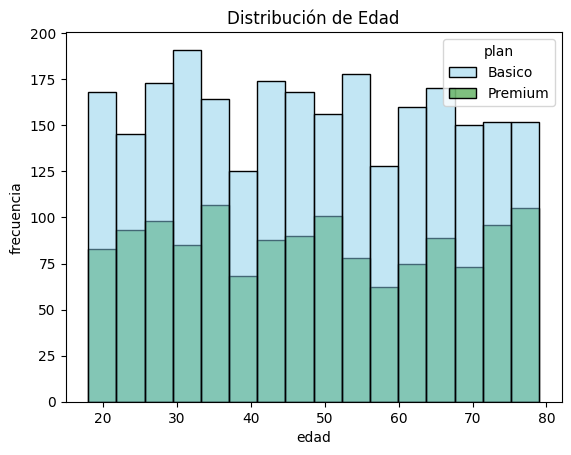

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Edad')
plt.ylabel('frecuencia')
plt.xlabel('edad')
plt.show()

💡Insights:
- Distribución muy estable, nos indica que la edad no es una variable que altera directamente el usuario del plan basico o premium. Nos muestra tambien que existe mayor personas que usan plan básico.

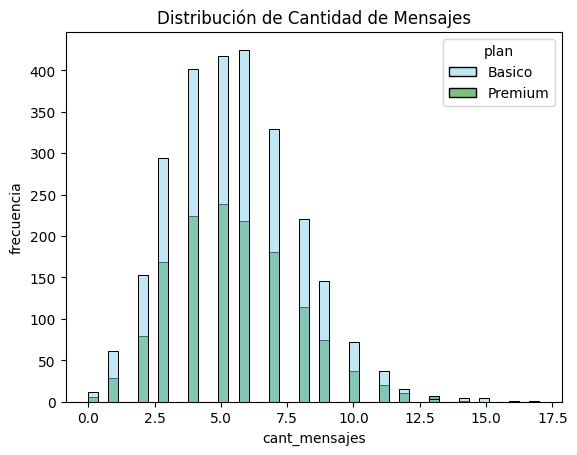

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Mensajes')
plt.ylabel('frecuencia')
plt.show()

💡Insights:
- Distribuición uniforme, nos muestra que existe una concentración entre 3 y 6 llamadas entre las personas que eligen el plan básico y premium. Destacandose que las personas que ejigen el plan basico se mantiene sin importar la cantidad de mensajes que se hagan.

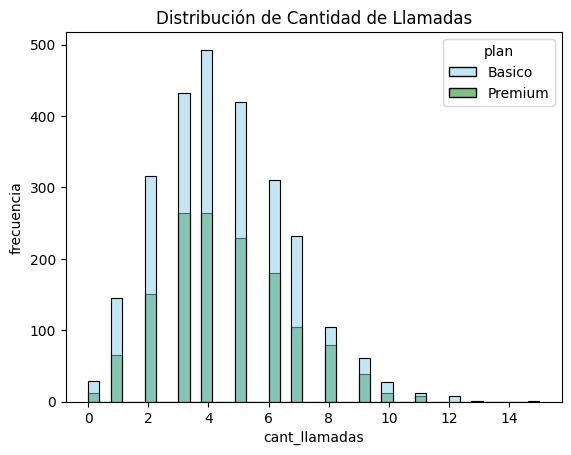

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Cantidad de Llamadas')
plt.ylabel('frecuencia')
plt.show()

💡Insights:
- Distribución uniforme, existe una concentración de la cantidad de llamadas de 4 en las personas que usan plan básico y premium. Destacandose que las personas que ejigen el plan basico se mantiene sin importar la cantidad de llamadas que se hagan.

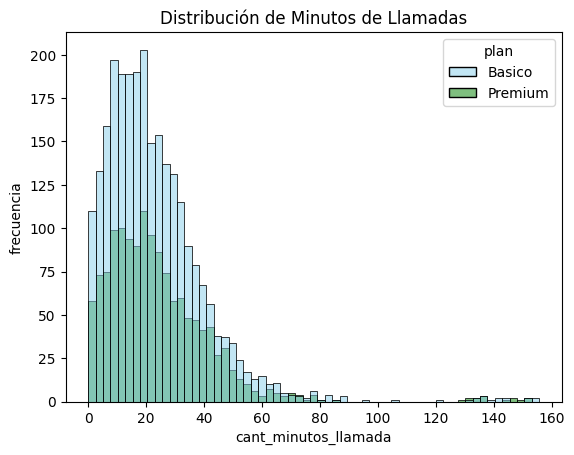

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de Minutos de Llamadas')
plt.ylabel('frecuencia')
plt.show()

💡Insights:
- Distribuición con sesgo hacia la derecha, nos muestra que la gran mayoria de usuarios realiza llamadas muy cortas. Por otro lado, las personas que ejigen el plan basico no se ven afectadas por la duracion de las llamadas que realizan.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Actividades realizadas:**  

- Usar **boxplots** para identificar visualmente outliers en las siguientes columnas:  

  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crear un **for** para generar los 4 boxplots automáticamente.
<br>

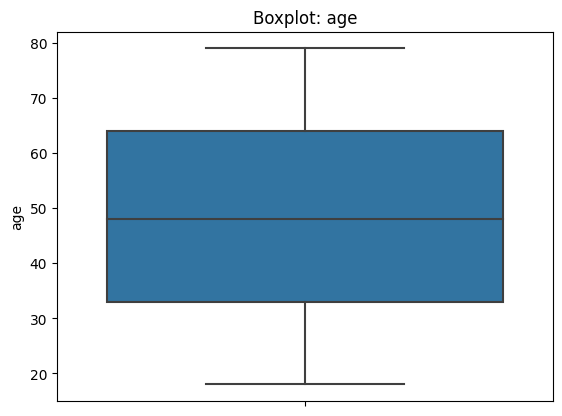

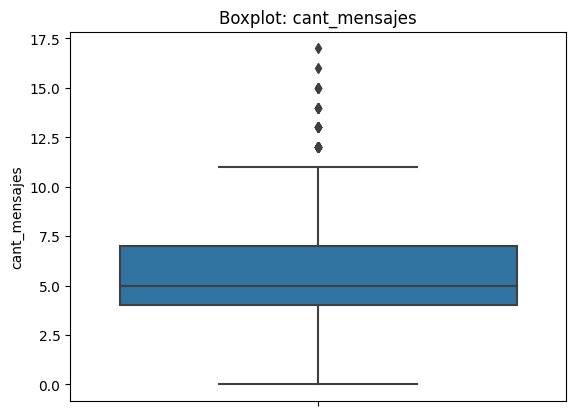

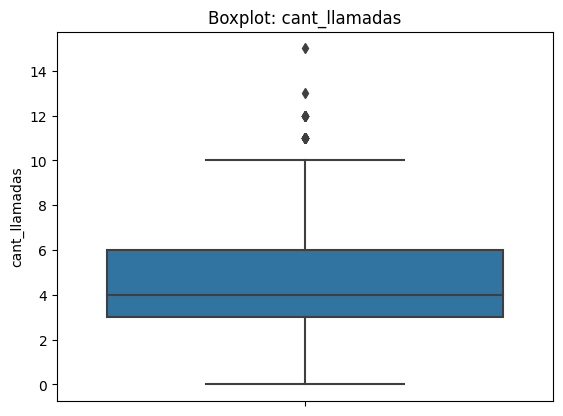

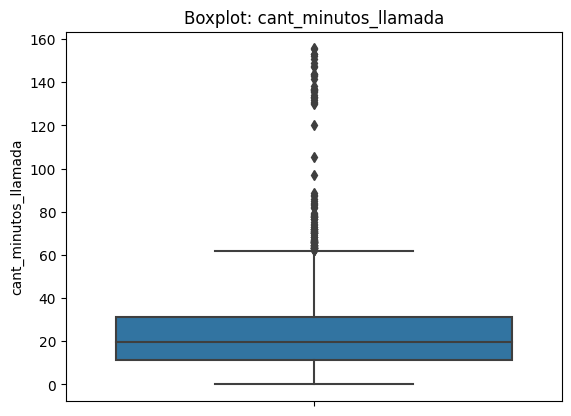

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,y=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights:
- Age: presenta una caja simetrica, no presenta outliers, con valores dentro de lo normal
- cant_mensajes: presenta una caja condensada hacia valores cercanos a 0, presenta multiples outliers
- cant_llamadas: presenta una caja condensada hacia valores cercanos a 0, presenta pocos outliers
- cant_minutos_llamada: presenta una caja condensada hacia valores cercanos a 0, presenta grandes cantidades de outliers. El bigote superior se encuentra mas distante de la caja

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR = Q1 - Q3
    Limite_inferior=Q1-1.5*IQR
    Limite_superior=Q3+1.5*IQR
    print(f"Limites {col}: Inferior={Limite_inferior}, Superior={Limite_superior}")


Limites cant_mensajes: Inferior=8.5, Superior=2.5
Limites cant_llamadas: Inferior=7.5, Superior=1.5
Limites cant_minutos_llamada: Inferior=41.5625, Superior=0.9724999999999966


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Los ouliers No se deben mantener por Sobrepasar los limites inferior y superior. Capar los valores extremos.
- cant_llamadas: mantener o no outliers, porqué? Los ouliers No se deben mantener por Sobrepasar los limites inferior y superior. Capar los valores extremos.
- cant_minutos_llamada: mantener o no outliers, porqué? Los ouliers No se deben mantener por Sobrepasar los limites inferior y superior. Capar los valores extremos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Actividades realizadas:**  
- Crear una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usar comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asignar:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if (row['cant_llamadas'] < 5) & (row['cant_mensajes'] < 5):
        return 'Bajo uso'
    elif (row['cant_llamadas'] < 10) & (row['cant_mensajes'] < 10):
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Actividades realizadas:**  
- Crear una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usar comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def segmentacion_clientes_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(segmentacion_clientes_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Actividades realizadas:**  
- Crear dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agregar título y etiquetas a los ejes en cada gráfico.

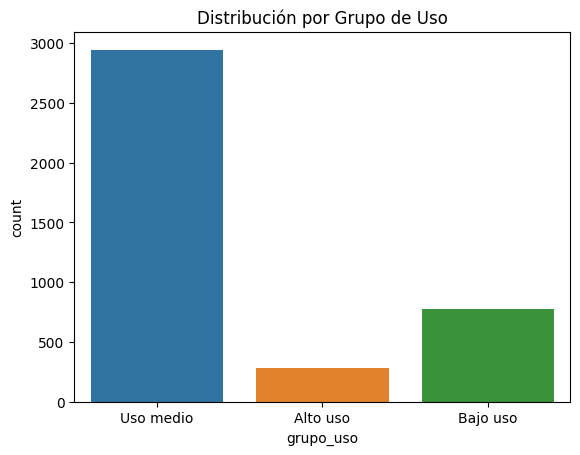

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución por Grupo de Uso')
plt.show()

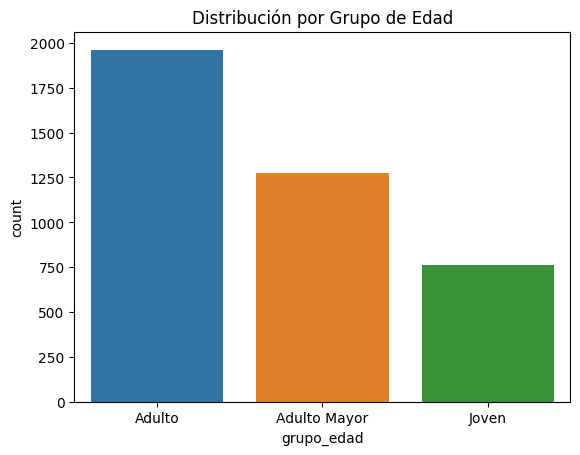

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución por Grupo de Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


✍️ **Análisis ejecutivo:**
- En el dataset users, la columna city tenía 469 valores nulos (11.7%) y churn_date tenía 3534 nulos (88.3%). En usage, la columna date tenía 50 valores nulos (0.1%). Además, duration y length tenían 55.1% y 44.7% de nulos respectivamente, pero se comprobó que eran "Missing At Random" (MAR) dependientes del tipo de servicio (llamada o mensaje). Se detectó también el valor atípico '-999' en la columna age y valores '?' en la columna city.  Por otro lado en la columna 'reg_date' se encontraron registros correspondientes al año 2026, lo cual es imposible dado que el análisis abarca hasta 2024.

- Se identificaron 02 segmentos: a) Por Edad (Joven, Adulto, Adulto Mayor): El comportamiento es sorprendentemente homogéneo. Independientemente de la edad, todos los grupos muestran una fuerte preferencia por el plan "Básico" sobre el "Premium". b) Por Uso (Bajo, Medio, Alto): Se identificó que la inmensa mayoría de los clientes (indistintamente de su edad o plan) pertenece al segmento de "Bajo uso", registrando menos de 5 llamadas y 5 mensajes en el periodo evaluado.

- El segmento de "Bajo uso" que está suscrito al plan "Premium" es sumamente valioso. Estos clientes pagan una tarifa mensual más alta (25 USD) que incluye 500 mensajes y 600 minutos, pero sus registros de uso indican que no consumen ni una fracción mínima de esos recursos, generando un alto margen de ganancia limpia para la empresa en esos rubros.

- Se detectaron valores extremos con usuarios que envían más de 100 mensajes, realizan más de 30 llamadas, o acumulan más de 1,100 minutos de voz. Esto demuestra la existencia de un nicho muy pequeño pero intenso.

- a) Reestructurar el marketing de planes: Dado que los mensajes de texto (SMS) y las llamadas telefónicas están en un claro desuso generalizado, se recomienda dejar de utilizar la "cantidad de minutos y mensajes" como el principal atractivo de venta. b) Enfoque en Datos: Es altamente probable que los usuarios contraten los planes por los datos de internet. ConnectaTel debería rediseñar sus ofertas para competir en cantidad de Gigabytes. c) Paquetes extra de llamadas: Como notamos que hay un grupo muy pequeño de clientes que sí hace muchísimas llamadas, ConnectaTel podría ofrecerles un paquete adicional de llamadas ilimitadas por un pago fijo al mes.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Inconsistencias y sentinels: Se detectaron edades imposibles (-999), lo que indica errores en la captura del formulario de registro, y valores como "?" en las ciudades.

- Fechas fuera de la realidad: Presencia de años futuros (2026) en las fechas de registro (reg_date), afectando la coherencia temporal del análisis histórico de 2024.

- Nulos condicionales: Una alta cantidad de nulos en duration y length dentro de la tabla de consumo, los cuales eran esperables (MAR) ya que un mensaje no tiene duración en minutos y una llamada no tiene longitud de caracteres.

🔍 **Segmentos por Edad**
- La base de clientes de ConnectaTel tiene una distribución uniforme; no hay una concentración atípica en ningún rango de edad en particular.

- El comportamiento de compra es idéntico en todos los grupos de edad (Jóvenes, Adultos y Adultos Mayores): todos prefieren abrumadoramente el plan "Básico" sobre el "Premium".


📊 **Segmentos por Nivel de Uso**
- Existe una dominancia absoluta del segmento de "Bajo uso". La inmensa mayoría de los clientes realiza menos de 5 llamadas y envía menos de 5 mensajes de texto.

- El grupo de "Alto uso" es una minoría extrema (outliers), pero acumula la mayor parte de la carga en minutos de red y envío de SMS.


➡️ - Los clientes de ConnectaTel no están valorando ni utilizando los servicios tradicionales de telecomunicaciones (voz y SMS). Es altamente probable que los usuarios mantengan sus líneas activas principalmente para el consumo de datos móviles (GB para internet) o simplemente como líneas receptoras, relegando las llamadas y mensajes a aplicaciones de terceros.


💡 **Recomendaciones**

- Enfocarse en vender datos de internet (GB): Como descubrimos que casi nadie usa los mensajes de texto ni las llamadas tradicionales, ConnectaTel debería dejar de promocionar los planes basándose en "minutos y mensajes". En su lugar, lo mejor es rediseñar los planes para ofrecer más Gigabytes, que es lo que realmente están buscando los clientes.

- Crear paquetes extra de llamadas ilimitadas: Aunque la mayoría no llama, hay un grupo muy pequeño de clientes que habla muchísimo. Para ellos, se puede crear un servicio adicional (como un extra en su recibo) que les dé llamadas ilimitadas por un pago fijo mensual, lo cual es ideal para negocios o call centers pequeños.

- Mejorar el formulario de registro de clientes: Hay que poner "candados" en el sistema para que no te deje guardar información si tiene errores obvios, como edades negativas (-999), símbolos en lugar de ciudades ("?") o años que todavía no pasan. Al evitar estos errores desde el momento en que el cliente se registra, la información de la empresa estará limpia y lista para analizarse.